# Video-Text-to-Text

> Everything to know about video LLMs: why the whole task is a token budget, how many frames actually help, the temporal-blindness test that most models fail, the mid-2026 landscape, and runnable code on a 12 GB card.

- skip_showdoc: true
- skip_exec: true

## 1. What is Video-Text-to-Text?

Video-text-to-text takes **a video plus a text prompt** and returns text. "Describe what happens in this clip." "At what point does the person pick up the cup?" "Is anyone violating the safety procedure?" "Summarise this lecture into bullet points."

It is `Multimodal/01_Image_Text_to_Text` with a time axis bolted on, and that one addition changes everything about the engineering. An image costs a few hundred to a few thousand visual tokens. A video is a sequence of images, so the naive cost is *frames x tokens-per-frame*, and a one-minute clip at 30 FPS is 1,800 frames. Every architectural decision in this family is a way of not paying that bill:

- **Sample fewer frames** (uniform 8-64 frames, regardless of clip length).
- **Spend fewer tokens per frame** (pixel shuffle, token merging, pooling, resamplers).
- **Merge across time** (2x2x2 spatiotemporal patches, temporal pooling, keyframe selection).
- **Remember rather than re-read** (memory banks, streaming KV caches).

**Input.** A video file or a list of frames, plus a chat prompt. Some models also take the audio track (see `Multimodal/00_Audio_Text_to_Text` and `08_Any_to_Any`); most ignore it, which is worth remembering when a question depends on speech.

**Output.** Free text: a description, an answer, a timestamp, a structured event list.

| Neighbouring task | Difference | Typical tools |
|---|---|---|
| Image-text-to-text (`Multimodal/01`) | One frame, no time | Qwen3-VL, InternVL3 |
| Video classification (`Computer_Vision/09`) | Fixed label set, no prompt, no free text | VideoMAE, TimeSformer, V-JEPA 2 |
| Video-to-video (`Computer_Vision/18`) | Video out, not text | AnimateDiff-vid2vid |
| Image-text-to-video (`Multimodal/03`) | Video **out** from an image and a prompt | LTX-Video, Wan 2.2 |
| Audio-text-to-text (`Multimodal/00`) | The soundtrack only | Qwen2-Audio, Granite Speech |

**The uncomfortable finding this notebook demonstrates.** Many video LLMs answer most benchmark questions almost as well when the frames are **shuffled** or when they see only **one** frame. That is not a bug in the models so much as a property of the benchmarks - a lot of "video" questions are really "what is in this scene" questions. Section 11 runs the ablation on real clips so you can see it rather than take my word for it.

---

## 2. Real-World Use Cases

| Use case | Domain | Consumes / produces | Dominant constraint |
|---|---|---|---|
| Video search and content discovery | Media, streaming (YouTube, Netflix tooling) | Clip -> summary, chapters, tags | Cost per hour of catalogue; consistency of vocabulary |
| Security and safety monitoring | Physical security, industrial | Camera feed + policy question -> alert with reason | Streaming latency; false-alarm rate; 24/7 cost per camera |
| Sports and broadcast analytics | Sports | Match footage + query -> events with timestamps | **Temporal precision**; frame-accurate localisation |
| Retail and loss prevention | Retail | Store camera -> behaviour description | Privacy and legal constraints; on-prem processing |
| Meeting and lecture summarisation | Productivity, EdTech | Screen recording + audio -> notes, slides, actions | Long context (an hour+); the audio track carries most of the content |
| Robotics and embodied agents | Robotics | Egocentric video + instruction -> subgoals | Control-loop latency; on-robot compute |
| Autonomous-vehicle scene understanding | Automotive | Multi-camera video + query -> scene description | Real-time; safety-critical calibration |
| Content moderation | Social platforms | Uploaded clip + policy -> label with justification | Throughput at upload scale; adversarial evasion |
| Medical procedure review | Healthcare | Surgical or ultrasound video -> phase and event annotation | Domain fine-tuning; regulatory validation |
| Ad and creative QA | Advertising | Ad video + brand checklist -> compliance report | Consistency; auditability of the judgement |

**What the benchmark hides.** Four realities.

*Long video is a retrieval problem, not a context problem.* A model with a 256k context can technically hold ~30 minutes of sparsely sampled frames, and it will still miss the two seconds that mattered. Production systems shot-detect, sample keyframes, embed and retrieve, then reason over the retrieved segment. Video-RAG is the pattern, not "feed the whole file".

*The audio track usually carries the answer.* For lectures, meetings and most user-generated content, the words are the content and the pixels are decoration. If your video LLM ignores the audio - and most do - you are throwing away the signal. The practical stack is ASR (`Audio/02`) plus a video LLM, or an omni model (`Multimodal/08`).

*Streaming is a different architecture.* Answering "what just happened" on a live feed cannot re-encode the whole history per question. It needs a memory bank or a rolling KV cache, and the open models that do this well (streaming VideoLLM variants) are still early.

*Cost per camera-hour decides everything.* At 1 FPS sampling and ~200 tokens per frame, one camera-hour is ~720k visual tokens. Multiply by 50 cameras and 24 hours and no VLM is affordable. Real deployments gate the VLM behind cheap motion detection or a small classifier and only invoke it on candidate segments.

---

## 3. How Modern Video LLMs Work

1. **Image models on the centre frame (2022-2023).** The honest baseline nobody wants to admit still works: run a strong image model on one frame. It fails on anything genuinely temporal and wins surprisingly often otherwise - which is why section 11 keeps it as a control.

2. **Frames as a bag of images (Video-ChatGPT, Video-LLaVA, 2023).** Sample N frames, encode each with a CLIP/SigLIP tower, pool spatially and temporally, concatenate into the LLM. Simple and effective; the pooling destroys fine spatial detail, and nothing in the design encodes *order* except position in the sequence.

3. **Explicit temporal modelling (2024).** Two lines. **Time-aware positional encoding**: Qwen2-VL's **M-RoPE** splits positional encoding into time, height and width components, so the model can reason about *when* as well as *where*; Qwen2.5-VL added absolute time alignment so it can answer with timestamps. **Spatiotemporal patching**: treat the clip as a 3D volume and merge 2x2x2 patches, halving the token count and giving the encoder genuine motion features.

4. **Token compression as the central problem (2024-2025).** LLaVA-NeXT-Video and its interleave variants, MiniCPM-V's resampler, and **SmolVLM2**'s aggressive pixel shuffle all attack the same number. SmolVLM2 is the extreme case: a 500M model that handles video on a phone because it spends ~64 tokens per frame instead of ~700.

5. **Long video: memory and retrieval (2025).** MovieChat's short-term/long-term memory banks, LongVA's context extension, Video-RAG pipelines that embed segments and retrieve. **Qwen3-VL** (2025) pushed native context to 256k (extensible to 1M) with **interleaved M-RoPE** and timestamp grounding, which is currently the strongest open answer for hour-scale video.

6. **Omni and streaming (2025-2026).** Qwen2.5/3-Omni handle video *and* its audio with TMRoPE aligning the two streams in time; VideoLLM-online and its successors process a live feed with a rolling cache. This is where the field is heading, because most valuable video has a soundtrack and arrives continuously.

**Mid-2026 state.** On short clips (under a minute) the good open models are genuinely strong. On long video the gap to closed models (Gemini's million-token context in particular) is still wide, and evaluation is unreliable: several 2024-25 papers showed that shuffling frames or dropping to a single frame barely moves scores on popular benchmarks, which means the benchmarks measure scene recognition more than temporal reasoning. Benchmarks built to fix this (Video-MME with its short/medium/long split, TemporalBench, TOMATO) are the ones worth quoting.

---

## 4. Evaluation Metrics

**Multiple-choice accuracy** is the workhorse. Video-MME, MVBench, TempCompass, NExT-QA and EgoSchema are all MCQ, scored as exact match on the option letter after light parsing. Chance is 25% for 4-way; always report it, because a model that refuses to answer in the requested format scores below chance for a formatting reason.

**Open-ended answers** (ActivityNet-QA, MSVD-QA, MSRVTT-QA) are scored by an **LLM judge** on correctness plus a 1-5 score. Cheap, reproducible-ish, and biased toward verbose answers.

**Captioning and description** metrics (CIDEr, BLEU) are as weak here as in `Computer_Vision/05_Image_to_Text`, and worse: dense video captions are long, so n-gram overlap says almost nothing.

**Temporal grounding** (Charades-STA, ActivityNet Captions) is scored with **IoU over time**: R@1 at IoU 0.5/0.7. This is the metric that actually requires the model to understand *when*, and it is where general video LLMs are weakest.

**The diagnostic that matters more than any of them.** Run your evaluation four ways: frames in order, **reversed**, **shuffled**, and **a single frame repeated**. If accuracy barely changes, the benchmark is not measuring temporal understanding and neither is your model. Section 11 implements exactly this, and it costs nothing to add to any evaluation.

**Cost.** Visual tokens per clip, seconds per query, and peak VRAM. Report tokens per *frame* too - it is the number that determines how long a clip you can afford.

The cell below implements MCQ parsing and the accuracy helper used by the benchmark.

---

In [ ]:
import re


def parse_choice(answer, options):
    "Map a free-text answer onto an option index. MCQ scoring is mostly parsing.\n\n    Models reply 'A', 'A.', '(A)', 'The answer is A', or the option text itself. A real\n    harness (lmms-eval) does the same thing; being sloppy here costs several points and\n    is the usual reason a good model 'fails' a benchmark.\n    "
    text = answer.strip()
    m = re.match(r"^\s*\(?([A-Z])\)?[\.\):,]?\s*$", text) or re.match(r"^\s*\(?([A-Z])\)?[\.\):,]\s", text)
    if m:
        idx = ord(m.group(1)) - ord("A")
        if 0 <= idx < len(options):
            return idx
    m = re.search(r"\b(?:answer|option)\b[^A-Z]{0,12}\(?([A-Z])\)?", text, re.IGNORECASE)
    if m:
        idx = ord(m.group(1).upper()) - ord("A")
        if 0 <= idx < len(options):
            return idx
    lowered = text.lower()
    hits = [i for i, o in enumerate(options) if o.lower() in lowered]
    if len(hits) == 1:
        return hits[0]
    return -1        # unparseable: counted as wrong, never silently dropped


def mcq_accuracy(predictions, golds):
    "Exact-match accuracy over parsed option indices, plus the unparseable rate."
    correct = sum(p == g for p, g in zip(predictions, golds))
    return {
        "accuracy": round(correct / max(len(golds), 1), 3),
        "unparsed": round(sum(p < 0 for p in predictions) / max(len(golds), 1), 3),
    }


OPTIONS = ["riding a bike", "flying a kite", "playing guitar", "eating spaghetti"]
for raw in ["B", "(B)", "B. flying a kite", "The answer is B.", "flying a kite",
            "I think the person is flying a kite outdoors.", "not sure"]:
    print(f"{raw!r:48s} -> {parse_choice(raw, OPTIONS)}")
print("\nchance level for 4 options:", round(1 / len(OPTIONS), 3))

'B'                                              -> 1
'(B)'                                            -> 1
'B. flying a kite'                               -> 1
'The answer is B.'                               -> -1
'flying a kite'                                  -> 1
'I think the person is flying a kite outdoors.'  -> 1
'not sure'                                       -> -1

chance level for 4 options: 0.25


## 5. Datasets

| Dataset | Contents | Size | Scope | License | Typical use |
|---|---|---|---|---|---|
| [Video-MME](https://huggingface.co/datasets/lmms-lab/Video-MME) | MCQs over short / medium / long videos (11 s to 1 h) | 2.7k QA / 900 videos | en | CC-BY-NC | **The** 2024-26 headline benchmark; the length split is its value |
| [MVBench](https://huggingface.co/datasets/OpenGVLab/MVBench) | 20 temporal-reasoning tasks built to defeat single-frame answering | 4k QA | en | MIT | Temporal ability breakdown |
| [TempCompass](https://huggingface.co/datasets/lmms-lab/TempCompass) | Speed, direction, order and attribute-change questions | 7.5k | en | Apache 2.0 | Fine-grained temporal probing |
| [NExT-QA](https://github.com/doc-doc/NExT-QA) | Causal and temporal questions over daily activities | 52k QA | en | MIT | Causal reasoning |
| [EgoSchema](https://huggingface.co/datasets/lmms-lab/egoschema) | 3-minute egocentric clips, very-long-form MCQs | 5k | en | Ego4D terms | Long-horizon understanding |
| [ActivityNet-QA](https://huggingface.co/datasets/lmms-lab/ActivityNetQA) | Open-ended QA over 800 h of activity video | 58k | en | Apache 2.0 | LLM-judged open answers |
| [Charades-STA](https://github.com/jiyanggao/TALL) | Sentence-to-moment localisation | 16k | en | non-commercial | **Temporal grounding** (IoU metrics) |
| [Kinetics-400](https://huggingface.co/datasets/nateraw/kinetics-mini) | 10 s action clips, 400 classes | 650k | n/a | CC-BY 4.0 | **This notebook's clips**; the classic action set |
| [Ego4D](https://ego4d-data.org/) | 3,670 h of egocentric video | 3.6k h | multi | Ego4D license | Egocentric pretraining and benchmarks |
| [LLaVA-Video-178K](https://huggingface.co/datasets/lmms-lab/LLaVA-Video-178K) | Synthetic dense captions and QA for training | 178k videos | en | Apache 2.0 | Video instruction tuning |

This notebook evaluates on **20 Kinetics-400 validation clips over 5 action classes** (the `nateraw/kinetics-mini` slice, a small ungated download), turned into a 5-way multiple-choice task. That is deliberately modest and deliberately *actiony*: it lets the temporal ablation in section 11 mean something, which a scene-recognition benchmark would not.

---

## 6. The Model Landscape (mid-2026)

Leaderboards: **[Video-MME](https://video-mme.github.io/home_page.html#leaderboard)** (the reference), **[MVBench](https://huggingface.co/spaces/OpenGVLab/MVBench_Leaderboard)** for temporal ability, and the **[OpenVLM Leaderboard](https://huggingface.co/spaces/opencompass/open_vlm_leaderboard)** video columns.

| Model | Params | License | Frames / context | Download | Best for |
|---|---|---|---|---|---|
| [SmolVLM2-500M-Video](https://huggingface.co/HuggingFaceTB/SmolVLM2-500M-Video-Instruct) | 0.5B | Apache 2.0 | ~64 frames | ~2 GB | **the cheapest usable video LLM**; runs on a phone |
| [SmolVLM2-2.2B](https://huggingface.co/HuggingFaceTB/SmolVLM2-2.2B-Instruct) | 2.2B | Apache 2.0 | ~64 frames | ~9 GB | on-device video with real quality |
| **[Qwen3-VL-2B/4B/8B](https://huggingface.co/Qwen/Qwen3-VL-2B-Instruct)** | 2-235B | Apache 2.0 | **256k** ctx, timestamp grounding | ~4.3 GB (2B) | this notebook's main model; long video, temporal localisation |
| [Qwen2.5-VL-3B/7B](https://huggingface.co/Qwen/Qwen2.5-VL-3B-Instruct) | 3-72B | Apache 2.0 | 32k, absolute-time M-RoPE | ~7.5 GB | the 2025 workhorse; wide tooling support |
| [InternVL3/3.5](https://huggingface.co/OpenGVLab/InternVL3-2B-hf) | 1-241B | MIT (varies) | 32k+ | ~4.2 GB (2B) | the other open lineage |
| [LLaVA-NeXT-Video-7B](https://huggingface.co/llava-hf/LLaVA-NeXT-Video-7B-hf) | 7B | LLaMA | 32 frames | ~14 GB | the 2024 reference; needs 4-bit here |
| [VideoLLaMA 3](https://huggingface.co/DAMO-NLP-SG/VideoLLaMA3-2B) | 2-7B | Apache 2.0 | adaptive frames | ~4 GB | strong small video model; custom code |
| [MiniCPM-V 4.x / o 2.6](https://huggingface.co/openbmb/MiniCPM-o-2_6) | 8B | Apache 2.0 (model) | video + audio | ~17 GB | on-device omni with the soundtrack |
| [Qwen2.5-Omni-3B](https://huggingface.co/Qwen/Qwen2.5-Omni-3B) | 5.5B | Apache 2.0 | video **+ audio**, TMRoPE | ~12 GB | when the answer is in the speech |
| Gemini 3, GPT-5.x | closed | API | ~1M tokens, hours of video | n/a | long-form video; still the frontier |

**Who wins what.** On **short-clip accuracy per parameter**, Qwen3-VL leads the open field. On **tokens per frame** - and therefore on how long a clip you can afford - SmolVLM2 is in a class of its own. On **long video**, closed models with million-token contexts still win, and the open answer is retrieval rather than context. On **audio-carrying video** (lectures, meetings), only the omni models are honest options; everything else silently ignores the most informative track.

**What fits this 12 GB box.** SmolVLM2-500M-Video (2 GB) and Qwen3-VL-2B (4.3 GB) run comfortably at 8-32 frames and are used in sections 8-9. SmolVLM2-2.2B fits in VRAM but is a 9 GB download. LLaVA-NeXT-Video-7B needs 4-bit; Qwen2.5-Omni-3B is a 12 GB download. The real limit here is not parameters - it is **frames x tokens per frame**, and section 10 measures exactly where it bites.

---

## 7. Setup

Every model loads through Hugging Face `transformers` - no vendor packages. Package roles:

- `transformers` (>=5.13) + `torch` - SmolVLM2 and Qwen3-VL via `AutoModelForImageTextToText`
- `accelerate` - `device_map` placement
- `torchcodec` (FFmpeg-backed, already a project dependency) - frame decoding
- `huggingface_hub` - the Kinetics clips
- `pillow` - frames and contact sheets
- `pyecharts` + `pandas` - benchmark charts and tables

**Decoding note.** `transformers`' own `load_video` defaults to a PyAV backend that is not installed here, so this notebook decodes with **torchcodec** and passes already-decoded frames into the chat template. Passing a list of PIL frames as `{"type": "video", "video": frames}` works for every model below and sidesteps the backend question entirely - as long as you also tell the processor two things it can no longer work out for itself: **not** to sample the frames again (`do_sample_frames=False`), and **how long they span** (`video_metadata`). Section 8 shows what goes wrong when you leave either out; it is the single most common way this task breaks.

**Frame sampling is a modelling decision, not a detail.** Uniform sampling across the whole clip is the default and what benchmarks assume. FPS-based sampling keeps the real time base (needed for timestamp answers) but makes cost proportional to clip length. Keyframe or shot-boundary sampling is what long-video pipelines use. Sections 10 and 11 show what the choice is worth.

All downloads land in `DL_tasks/datasets/`, which is gitignored.

---

In [ ]:
# Everything runs through Hugging Face transformers - no model-specific packages.
# %pip install -q torch transformers accelerate torchcodec pillow pandas pyecharts

In [ ]:
import ctypes
import ctypes.util
import gc
import time
from pathlib import Path

import numpy as np
import torch
from dotenv import find_dotenv, load_dotenv

# Knowledge/.env sets HF_TOKEN - authenticated HF Hub requests get higher rate limits
load_dotenv(find_dotenv(usecwd=True))

device = "cuda:0" if torch.cuda.is_available() else "cpu"
dtype = torch.float16 if device != "cpu" else torch.float32
if device != "cpu":
    print(torch.cuda.get_device_name(0))
print("device:", device, "| dtype:", dtype)


def vram(tag=""):
    "Report current GPU memory (allocated / reserved). No-op on CPU."
    if torch.cuda.is_available():
        alloc = torch.cuda.memory_allocated() / 1e9
        reserved = torch.cuda.memory_reserved() / 1e9
        print(f"VRAM {tag:22s} {alloc:5.2f} GB allocated / {reserved:5.2f} GB reserved")


def free_memory():
    "Collect garbage and hand freed VRAM back to the CUDA allocator.\n\n    Call right after `del`-ing a model you are done with: `del model; free_memory()`.\n    `del` drops the Python reference; this reclaims the RAM and releases the VRAM.\n    "
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()
    # glibc keeps freed CPU allocations in its arenas instead of returning them to the
    # OS, so RSS compounds across sections - and decoded frame arrays are large.
    # malloc_trim(0) hands the freed arenas back. See
    # dl-visualization-and-memory.instructions.md - not optional on a 12 GB box.
    try:
        ctypes.CDLL(ctypes.util.find_library("c") or "libc.so.6").malloc_trim(0)
    except Exception:
        pass


# All downloads go to DL_tasks/datasets/ (gitignored)
DATA_DIR = Path("../../datasets")
DATA_DIR.mkdir(exist_ok=True)
HF_CACHE = str(DATA_DIR / "hf_cache")

NVIDIA GeForce RTX 3060
device: cuda:0 | dtype: torch.float16


In [ ]:
from PIL import Image

# Decoder backend: torchcodec (FFmpeg-backed, in this repo's deps) -> PyAV -> error.
_BACKEND = None
try:
    from torchcodec.decoders import VideoDecoder
    _BACKEND = "torchcodec"
except Exception:
    try:
        import av
        _BACKEND = "pyav"
    except Exception:
        _BACKEND = None
print("decoder backend:", _BACKEND)


def read_video(path, num_frames=16):
    "Uniformly sample `num_frames` RGB frames across the whole clip -> (PIL frames, seconds).\n\n    The clip duration comes back with the frames because the frames alone do not say how\n    much time they span, and every model below builds timestamps out of that span. See\n    `video_meta` in section 8.\n    "
    if _BACKEND == "torchcodec":
        dec = VideoDecoder(str(path))
        total = dec.metadata.num_frames
        seconds = dec.metadata.duration_seconds
        want = np.linspace(0, total - 1, num_frames).round().astype(int)
        arr = dec.get_frames_at(indices=want.tolist()).data.permute(0, 2, 3, 1).numpy()
    elif _BACKEND == "pyav":
        container = av.open(str(path))
        stream = container.streams.video[0]
        total = stream.frames or 300
        seconds = (float(stream.duration * stream.time_base) if stream.duration
                   else total / float(stream.average_rate or 30))
        want = set(np.linspace(0, total - 1, num_frames).round().astype(int).tolist())
        keep, last = {}, max(want)
        for i, frame in enumerate(container.decode(video=0)):
            if i in want:
                keep[i] = frame.to_ndarray(format="rgb24")
            if i >= last:
                break
        container.close()
        arr = np.stack([keep[i] for i in sorted(keep)])
    else:
        raise RuntimeError("no video decoder: `pip install torchcodec` (needs FFmpeg) or `pip install av`")
    return [Image.fromarray(f) for f in arr], float(seconds)


def contact_sheet(frames, cols=8, width=160):
    "Tile frames into one image so a clip is visible in the rendered docs."
    n = len(frames)
    rows = (n + cols - 1) // cols
    h = int(width * frames[0].height / frames[0].width)
    sheet = Image.new("RGB", (cols * width, rows * h), "black")
    for i, f in enumerate(frames):
        sheet.paste(f.resize((width, h)), ((i % cols) * width, (i // cols) * h))
    return sheet

decoder backend: torchcodec


20 clips over 5 classes: ['archery', 'bowling', 'flying kite', 'high jump', 'marching']
demo clip: eating_spaghetti.mp4 | 16 sampled frames at (640, 360) | 10.0s long


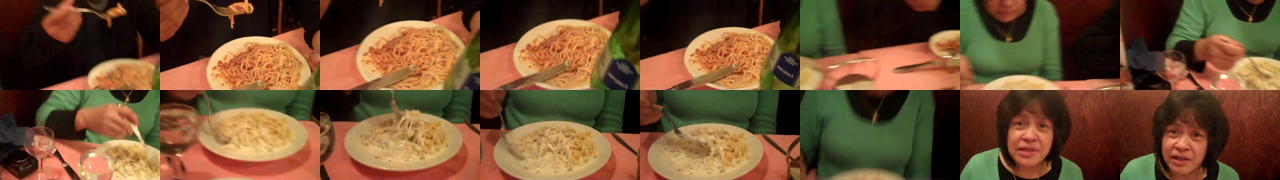

cached 20 clips x 32 frames (2.7-10.0s each)


In [ ]:
from huggingface_hub import hf_hub_download, list_repo_files
from IPython.display import display

# Eval set: Kinetics-400 validation clips over 5 action classes. Actions rather than
# scenes, so the temporal ablation in section 11 has something to measure.
EVAL_REPO = "nateraw/kinetics-mini"
files = sorted(f for f in list_repo_files(EVAL_REPO, repo_type="dataset")
               if f.startswith("val/") and f.endswith(".mp4"))

CLIPS_PER_CLASS = 4          # 4 x 5 classes = 20 clips: a smoke test, not a benchmark
by_class = {}
for f in files:
    by_class.setdefault(f.split("/")[1], []).append(f)

eval_set = []                # (local_path, label)
for cls, paths in sorted(by_class.items()):
    for f in paths[:CLIPS_PER_CLASS]:
        local = hf_hub_download(EVAL_REPO, f, repo_type="dataset", cache_dir=HF_CACHE)
        eval_set.append((local, cls.replace("_", " ")))

CLASSES = sorted({lbl for _, lbl in eval_set})
print(f"{len(eval_set)} clips over {len(CLASSES)} classes: {CLASSES}")

# One demo clip for the per-model sections (the transformers docs' own sample).
SAMPLE = hf_hub_download("nielsr/video-demo", "eating_spaghetti.mp4",
                         repo_type="dataset", cache_dir=HF_CACHE)

sample_frames, SAMPLE_SECONDS = read_video(SAMPLE, 16)
print(f"demo clip: {Path(SAMPLE).name} | {len(sample_frames)} sampled frames "
      f"at {sample_frames[0].size} | {SAMPLE_SECONDS:.1f}s long")
display(contact_sheet(sample_frames))

# Decode the eval clips ONCE at the maximum frame count any section needs, then
# subsample from the cache. Decoding is slow and this keeps it off the timing numbers.
# `clip_seconds` is kept alongside: the frames stop carrying their own time base the
# moment they leave the decoder, and every `ask` below wants it back.
MAX_FRAMES = 32
frame_cache, clip_seconds = {}, {}
for path, _ in eval_set:
    frame_cache[path], clip_seconds[path] = read_video(path, MAX_FRAMES)


def subsample(frames, n):
    "Uniformly pick n frames out of a longer cached list, preserving order."
    idx = np.linspace(0, len(frames) - 1, n).round().astype(int)
    return [frames[i] for i in idx]


print(f"cached {len(frame_cache)} clips x {MAX_FRAMES} frames "
      f"({min(clip_seconds.values()):.1f}-{max(clip_seconds.values()):.1f}s each)")

## 8. SmolVLM2-500M-Video - the cheap end

SmolVLM2 (Hugging Face, 2025) is the answer to "what is the smallest thing that can watch a video". The 500M video variant runs in about 1-2 GB of VRAM and is genuinely deployable on a phone.

The trick is the same as in `Multimodal/01`: a **pixel-shuffle** projector rearranges spatial detail into channels, cutting the token count per frame by 4x or 9x before the LLM sees anything. On images that is a nice saving; on video, where the cost is *frames x tokens per frame*, it is the difference between 8 frames and 64.

What you trade is fine detail - small text and subtle motion are where the compression shows. What you gain is a model that can look at a whole clip instead of a few frames of it.

The cell also fixes the universal calling convention for the rest of the notebook: a `{"type": "video", "video": [PIL frames]}` content block plus the clip duration. **Pre-decoded frames need two extra kwargs, and both matter:**

- **`do_sample_frames=False`.** The processor samples frames itself by default, so without this it re-samples frames that `read_video` already sampled. SmolVLM raises `ValueError: ... no video metadata was provided`; Qwen3-VL fails *silently and worse*, cutting 16 frames down to about 1 at its default 2 FPS, which looks like a working call and quietly turns a video model into a single-frame one.
- **`video_metadata`** (`total_num_frames`, `fps`, `duration`, `frames_indices`). Both models write a timestamp beside every frame in the prompt. With no metadata `transformers` assumes the source was 24 FPS, so 16 frames spanning a 10-second clip get labelled 0.0s to 0.6s. The model is then told the whole thing happened inside the first second, which is why `read_video` returns the clip duration and every `ask` takes it.

---

In [ ]:
from transformers import AutoModelForImageTextToText, AutoProcessor


def video_meta(frames, seconds):
    "Tell the processor what stretch of time a list of pre-sampled frames covers.\n\n    Hand a processor bare PIL frames and it has no time base, so `transformers` assumes\n    the source ran at 24 FPS: 16 frames become a 0.6-second clip and every timestamp in\n    the prompt is wrong by more than an order of magnitude. `frames_indices` is required\n    too - the chat template builds timestamps from it and raises without it.\n    "
    return [{"total_num_frames": len(frames), "fps": len(frames) / seconds,
             "duration": float(seconds), "frames_indices": list(range(len(frames)))}]


def load_video_lm(model_id, **kw):
    "Load a video-capable VLM and return (ask, handles). `ask(frames, prompt, seconds) -> text`."
    processor = AutoProcessor.from_pretrained(model_id, cache_dir=HF_CACHE)
    model = AutoModelForImageTextToText.from_pretrained(
        model_id, dtype=dtype, device_map=device, low_cpu_mem_usage=True,
        cache_dir=HF_CACHE, **kw,
    ).eval()

    def ask(frames, prompt, seconds=None, max_new_tokens=160, return_tokens=False):
        "PIL frames + how long they span + a prompt -> the model's text (prompt echo stripped)."
        frames = list(frames)
        content = [{"type": "video", "video": frames}, {"type": "text", "text": prompt}]
        # do_sample_frames=False is not optional: these frames were already sampled by
        # read_video/subsample, and left at the default the processor samples them AGAIN.
        # SmolVLM raises outright ("no video metadata was provided"); Qwen quietly cuts 16
        # frames to ~1 at its default 2 FPS, which looks like it worked and is not.
        proc_kwargs = {"do_sample_frames": False}
        if seconds:
            proc_kwargs["video_metadata"] = video_meta(frames, seconds)
        inputs = processor.apply_chat_template(
            [{"role": "user", "content": content}],
            add_generation_prompt=True, tokenize=True, return_dict=True,
            return_tensors="pt", processor_kwargs=proc_kwargs,
        ).to(model.device)
        n = inputs["input_ids"].shape[1]
        with torch.inference_mode():
            out = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)
        text = processor.batch_decode(out[:, n:], skip_special_tokens=True)[0].strip()
        return (text, n) if return_tokens else text

    return ask, [model, processor]


smol_ask, smol_handles = load_video_lm("HuggingFaceTB/SmolVLM2-500M-Video-Instruct")
vram("smolvlm2-500m loaded")

for prompt in ["Describe what happens in this video in two sentences.",
               "What single action is the person performing? Answer in three words."]:
    t0 = time.perf_counter()
    answer = smol_ask(sample_frames, prompt, SAMPLE_SECONDS)
    print(f"> {prompt}\n  [{time.perf_counter() - t0:4.1f}s] {answer}\n")

# The number that governs everything: tokens per frame.
_, n8 = smol_ask(subsample(sample_frames, 8), "hi", SAMPLE_SECONDS,
                 max_new_tokens=1, return_tokens=True)
_, n16 = smol_ask(sample_frames, "hi", SAMPLE_SECONDS, max_new_tokens=1, return_tokens=True)
print(f"prompt tokens: 8 frames -> {n8}, 16 frames -> {n16}  "
      f"=> ~{(n16 - n8) / 8:.0f} tokens per frame")

for h in smol_handles:
    del h
del smol_ask, smol_handles
free_memory()
vram("after smolvlm2")

[transformers] Model config: pad_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 128002. This may result in unexpected behavior.


Loading weights:   0%|          | 0/489 [00:00<?, ?it/s]

VRAM smolvlm2-500m loaded    1.01 GB allocated /  1.06 GB reserved
> Describe what happens in this video in two sentences.
  [ 1.3s] A person in a green sweater is seen eating spaghetti with a fork and knife, while another person in a green sweater is seated at a table with a plate of spaghetti and a glass of wine.

> What single action is the person performing? Answer in three words.
  [ 0.5s] Eating.

prompt tokens: 8 frames -> 656, 16 frames -> 1272  => ~77 tokens per frame
VRAM after smolvlm2          0.01 GB allocated /  0.01 GB reserved


## 9. Qwen3-VL-2B - timestamps and long clips

The strong option at this size, and the one with real temporal machinery:

- **Interleaved M-RoPE** encodes time, height and width as separate positional components interleaved across the embedding, rather than time as a flat sequence offset. That is what lets it reason about ordering and duration instead of just "these frames came in some order".
- **Timestamp grounding**: it was trained to answer *when* something happens, not only *what*, so "at what second does X occur" is in scope. (Accuracy on that is much lower than on "what" questions - temporal grounding is the hardest column on every benchmark.)
- **256k native context** (extensible to 1M), which at a few hundred tokens per frame is genuinely tens of minutes of sparsely sampled video.

Compare the two models' answers below on the same frames: the difference is not usually *what* they see but how precisely they can talk about the sequence.

---

In [ ]:
qwen_id = "Qwen/Qwen3-VL-2B-Instruct"
qwen_ask, qwen_handles = load_video_lm(qwen_id)
vram("qwen3-vl loaded")

for prompt in ["Describe what happens in this video in two sentences.",
               "What single action is the person performing? Answer in three words.",
               "Describe the video as a sequence of steps, in order, one per line."]:
    t0 = time.perf_counter()
    answer = qwen_ask(sample_frames, prompt, SAMPLE_SECONDS)
    print(f"> {prompt}\n  [{time.perf_counter() - t0:4.1f}s] {answer}\n")

# Temporal localisation: the question type that separates a video model from an image
# model applied N times. Expect this to be the least reliable answer in the notebook.
# This is also the question that `video_meta` exists for - Qwen3-VL writes a timestamp
# next to each frame in the prompt, and without the clip duration those timestamps say
# the whole thing happened inside the first second.
print("> temporal grounding")
print(" ", qwen_ask(sample_frames,
                    f"The clip is about {SAMPLE_SECONDS:.0f} seconds long. In which second does "
                    "the main action first become visible? Answer with a single number.",
                    SAMPLE_SECONDS, max_new_tokens=32))

_, n8 = qwen_ask(subsample(sample_frames, 8), "hi", SAMPLE_SECONDS,
                 max_new_tokens=1, return_tokens=True)
_, n16 = qwen_ask(sample_frames, "hi", SAMPLE_SECONDS, max_new_tokens=1, return_tokens=True)
print(f"\nprompt tokens: 8 frames -> {n8}, 16 frames -> {n16}  "
      f"=> ~{(n16 - n8) / 8:.0f} tokens per frame")

Loading weights:   0%|          | 0/625 [00:00<?, ?it/s]

VRAM qwen3-vl loaded         4.26 GB allocated /  4.27 GB reserved
> Describe what happens in this video in two sentences.
  [ 1.3s] A woman is eating spaghetti with a fork and knife. She is wearing a green sweater and has a gold necklace. She is sitting at a table with a pink tablecloth.

> What single action is the person performing? Answer in three words.
  [ 0.7s] eating

> Describe the video as a sequence of steps, in order, one per line.
  [ 3.5s] A person is eating spaghetti with meat sauce. They are using a fork to eat the spaghetti. The person is wearing a green shirt. The person is sitting at a table with a pink tablecloth. There is a glass of water on the table. The person is eating the spaghetti with a fork. The person is eating the spaghetti with a fork. The person is eating the spaghetti with a fork. The person is eating the spaghetti with a fork. The person is eating the spaghetti with a fork. The person is eating the spaghetti with a fork. The person is eating the spagh

## 10. How many frames do you actually need?

The central engineering question of this family, and it has a measurable answer for *your* data.

The cell below runs the same 5-way action-recognition task at 1, 4, 8, 16 and 32 frames, and reports accuracy, prompt tokens and latency at each. Three things usually show up:

1. **A single frame is a strong baseline.** For scene-heavy questions it is nearly as good as a full clip, which is exactly the criticism levelled at video benchmarks.
2. **Accuracy saturates early.** Most of the gain arrives by 8 frames; beyond that the curve flattens while cost keeps rising linearly.
3. **Cost is linear and unforgiving.** Tokens, latency and VRAM all scale with frame count, so "just use more frames" runs out of card quickly.

Where the saturation point sits depends entirely on the question type: action recognition saturates fast, counting and ordering questions do not.

---

In [ ]:
def mcq_prompt(options):
    "One 5-way action question, formatted the way MCQ benchmarks expect."
    lines = "\n".join(f"{chr(ord('A') + i)}. {o}" for i, o in enumerate(options))
    return ("Watch the video and answer the multiple-choice question.\n"
            "What action is the person performing?\n"
            f"{lines}\n"
            "Answer with the option letter only.")


PROMPT = mcq_prompt(CLASSES)
golds = [CLASSES.index(label) for _, label in eval_set]

sweep = []
for n_frames in (1, 4, 8, 16, 32):
    preds, tokens, t0 = [], 0, time.perf_counter()
    for path, _ in eval_set:
        frames = subsample(frame_cache[path], n_frames)
        text, n_prompt = qwen_ask(frames, PROMPT, clip_seconds[path],
                                  max_new_tokens=16, return_tokens=True)
        preds.append(parse_choice(text, CLASSES))
        tokens += n_prompt
    elapsed = time.perf_counter() - t0
    scores = mcq_accuracy(preds, golds)
    sweep.append({"frames": n_frames, **scores,
                  "prompt_tokens": round(tokens / len(eval_set)),
                  "sec_per_clip": round(elapsed / len(eval_set), 2)})
    print(f"{n_frames:2d} frames -> accuracy {scores['accuracy']:.3f}  "
          f"({sweep[-1]['prompt_tokens']} tokens, {sweep[-1]['sec_per_clip']:.2f}s per clip)")

print(f"\nchance level: {1 / len(CLASSES):.3f}")

 1 frames -> accuracy 0.900  (516 tokens, 0.24s per clip)
 4 frames -> accuracy 0.950  (975 tokens, 0.42s per clip)
 8 frames -> accuracy 1.000  (1892 tokens, 0.79s per clip)
16 frames -> accuracy 1.000  (3728 tokens, 1.56s per clip)
32 frames -> accuracy 1.000  (6375 tokens, 2.74s per clip)

chance level: 0.200


In [ ]:
import pandas as pd
from pyecharts import options as opts
from pyecharts.charts import Line

sweep_df = pd.DataFrame(sweep)
line = (
    Line()
    .add_xaxis([str(r["frames"]) for r in sweep])
    .add_yaxis("accuracy x100", [round(r["accuracy"] * 100, 1) for r in sweep])
    .add_yaxis("prompt tokens / 100", [round(r["prompt_tokens"] / 100, 1) for r in sweep])
    .add_yaxis("seconds per clip x10", [round(r["sec_per_clip"] * 10, 1) for r in sweep])
    .set_global_opts(
        title_opts=opts.TitleOpts(
            title="Accuracy and cost vs frame count",
            subtitle=f"Qwen3-VL-2B, {len(eval_set)} Kinetics clips, 5-way MCQ, RTX 3060 12 GB",
        ),
        xaxis_opts=opts.AxisOpts(name="frames sampled"),
        yaxis_opts=opts.AxisOpts(name="scaled value"),
        tooltip_opts=opts.TooltipOpts(trigger="axis"),
    )
)
line.render_notebook()

## 11. The temporal-blindness test

The diagnostic every video evaluation should include and almost none do.

Take the frames you were going to feed the model and mutate the **time axis** only:

| Variant | Frames | What it tests |
|---|---|---|
| `forward` | in order | the baseline |
| `reversed` | reverse order | does order matter at all? |
| `shuffled` | random permutation | is any temporal structure being used? |
| `static` | the centre frame repeated N times | is this really a single-image task? |

If `shuffled` and `static` score close to `forward`, then whatever the model is doing, it is not temporal reasoning - and the question set is really a scene-recognition set. That is a fact about your **benchmark** as much as about your model, and it is worth knowing before you spend money on a bigger video LLM.

Kinetics action recognition is a mild case: many actions are identifiable from one frame ("playing guitar"), while some genuinely need motion ("opening" vs "closing"). Benchmarks built to defeat single-frame answering - MVBench, TempCompass, TOMATO - show much larger gaps.

---

In [ ]:
rng = np.random.default_rng(0)
N_ABLATION = 8

VARIANTS = {
    "forward": lambda f: f,
    "reversed": lambda f: f[::-1],
    "shuffled": lambda f: [f[i] for i in rng.permutation(len(f))],
    "static (centre frame x N)": lambda f: [f[len(f) // 2]] * len(f),
    "single frame": lambda f: [f[len(f) // 2]],
}

# Every variant is presented as spanning the same clip duration, so the timeline the
# model is told about is held constant and only the frame content moves. Mutating the
# timestamps too would confound the two.
ablation = {}
for name, transform in VARIANTS.items():
    preds = []
    for path, _ in eval_set:
        frames = transform(subsample(frame_cache[path], N_ABLATION))
        preds.append(parse_choice(
            qwen_ask(frames, PROMPT, clip_seconds[path], max_new_tokens=16), CLASSES))
    ablation[name] = mcq_accuracy(preds, golds)["accuracy"]
    print(f"{name:26s} accuracy {ablation[name]:.3f}")

drop = ablation["forward"] - ablation["shuffled"]
print(f"\nforward - shuffled = {drop:+.3f}")
print("A gap near zero means the model is not using frame order on this question set -\n"
      "and that the question set is closer to scene recognition than to video understanding.")

forward                    accuracy 1.000
reversed                   accuracy 1.000
shuffled                   accuracy 1.000
static (centre frame x N)  accuracy 1.000
single frame               accuracy 1.000

forward - shuffled = +0.000
A gap near zero means the model is not using frame order on this question set -
and that the question set is closer to scene recognition than to video understanding.


In [ ]:
from pyecharts.charts import Bar

bar = (
    Bar()
    .add_xaxis(list(ablation))
    .add_yaxis("accuracy x100", [round(v * 100, 1) for v in ablation.values()])
    .set_global_opts(
        title_opts=opts.TitleOpts(
            title="Temporal-blindness ablation",
            subtitle=f"Qwen3-VL-2B, {N_ABLATION} frames, {len(eval_set)} clips - "
                     f"chance is {100 / len(CLASSES):.0f}%",
        ),
        xaxis_opts=opts.AxisOpts(name="frame-order variant", axislabel_opts=opts.LabelOpts(rotate=20)),
        yaxis_opts=opts.AxisOpts(name="accuracy %", max_=100),
        tooltip_opts=opts.TooltipOpts(trigger="axis"),
    )
)
bar.render_notebook()

## 12. Head-to-head Benchmark

Two video LLMs on the **same 20 clips**, the **same 8 sampled frames**, the **same MCQ prompt** and the **same parser**: SmolVLM2-500M-Video and Qwen3-VL-2B. Each model is loaded, measured and **freed before the next one loads**, so VRAM stays flat.

Reported: accuracy, the unparseable-answer rate (a formatting failure, tracked separately so it is not mistaken for a vision failure), prompt tokens per clip, seconds per clip, and the shuffled-frame accuracy from section 11's diagnostic run alongside.

**Read this as a smoke test, not a leaderboard.** Twenty clips and a 5-way choice gives an accuracy with an uncertainty of roughly plus or minus 10 points, chance is 20%, and Kinetics action recognition is far easier than Video-MME. What the sample *does* show honestly is the cost-per-clip difference between a 0.5B and a 2B video model on this card, and whether either of them uses frame order.

---

In [ ]:
for h in qwen_handles:
    del h
del qwen_ask, qwen_handles
free_memory()
vram("before benchmark")

BENCH_FRAMES = 8


def benchmark(name, model_id):
    "Load, answer every clip forward and shuffled, score, free."
    ask, handles = load_video_lm(model_id)
    preds, tokens, t0 = [], 0, time.perf_counter()
    for path, _ in eval_set:
        frames = subsample(frame_cache[path], BENCH_FRAMES)
        text, n_prompt = ask(frames, PROMPT, clip_seconds[path],
                             max_new_tokens=16, return_tokens=True)
        preds.append(parse_choice(text, CLASSES))
        tokens += n_prompt
    elapsed = time.perf_counter() - t0

    shuffled = []
    for path, _ in eval_set:
        frames = subsample(frame_cache[path], BENCH_FRAMES)
        frames = [frames[i] for i in rng.permutation(len(frames))]
        shuffled.append(parse_choice(
            ask(frames, PROMPT, clip_seconds[path], max_new_tokens=16), CLASSES))

    scores = mcq_accuracy(preds, golds)
    for h in handles:
        del h
    del ask, handles
    free_memory()
    vram(f"after {name}")
    return {"model": name, **scores,
            "shuffled_acc": mcq_accuracy(shuffled, golds)["accuracy"],
            "prompt_tokens": round(tokens / len(eval_set)),
            "sec_per_clip": round(elapsed / len(eval_set), 2),
            "preds": preds}


results = [
    benchmark("smolvlm2-500m-video", "HuggingFaceTB/SmolVLM2-500M-Video-Instruct"),
    benchmark("qwen3-vl-2b", qwen_id),
]
vram("benchmark done")

VRAM before benchmark        0.01 GB allocated /  0.01 GB reserved


Loading weights:   0%|          | 0/489 [00:00<?, ?it/s]

VRAM after smolvlm2-500m-video  0.01 GB allocated /  0.01 GB reserved


Loading weights:   0%|          | 0/625 [00:00<?, ?it/s]

VRAM after qwen3-vl-2b       0.01 GB allocated /  0.01 GB reserved
VRAM benchmark done          0.01 GB allocated /  0.01 GB reserved


In [ ]:
df = pd.DataFrame([{k: v for k, v in r.items() if k != "preds"} for r in results])
df["order_gain"] = (df["accuracy"] - df["shuffled_acc"]).round(3)
df.sort_values("accuracy", ascending=False)

,model,accuracy,unparsed,shuffled_acc,prompt_tokens,sec_per_clip,order_gain
0,smolvlm2-500m-video,1.0,0.0,0.95,705,0.29,0.05
1,qwen3-vl-2b,1.0,0.0,1.00,1892,0.80,0.00


In [ ]:
names = [r["model"] for r in results]
bar = (
    Bar()
    .add_xaxis(names)
    .add_yaxis("accuracy % (frames in order)", [round(r["accuracy"] * 100, 1) for r in results])
    .add_yaxis("accuracy % (frames shuffled)", [round(r["shuffled_acc"] * 100, 1) for r in results])
    .set_global_opts(
        title_opts=opts.TitleOpts(
            title=f"{len(eval_set)} Kinetics clips, {BENCH_FRAMES} frames, 5-way MCQ",
            subtitle=f"RTX 3060 12 GB - smoke test, not a leaderboard; chance is "
                     f"{100 / len(CLASSES):.0f}%",
        ),
        xaxis_opts=opts.AxisOpts(name="model"),
        yaxis_opts=opts.AxisOpts(name="accuracy %", max_=100),
        tooltip_opts=opts.TooltipOpts(trigger="axis"),
    )
)
bar.render_notebook()

In [ ]:
from pyecharts.charts import Scatter

# Accuracy against cost per clip - the trade that decides what you would deploy on 50 cameras.
scatter = Scatter()
scatter.add_xaxis([round(r["sec_per_clip"], 2) for r in results])
for r in results:
    scatter.add_yaxis(r["model"], [[round(r["sec_per_clip"], 2), round(r["accuracy"] * 100, 1)]],
                      symbol_size=18, label_opts=opts.LabelOpts(is_show=False))
scatter.set_global_opts(
    title_opts=opts.TitleOpts(title="Accuracy vs seconds per clip",
                              subtitle="up and to the left is better"),
    xaxis_opts=opts.AxisOpts(type_="value", name="seconds / clip"),
    yaxis_opts=opts.AxisOpts(type_="value", name="accuracy %"),
    tooltip_opts=opts.TooltipOpts(trigger="item"),
)
scatter.render_notebook()

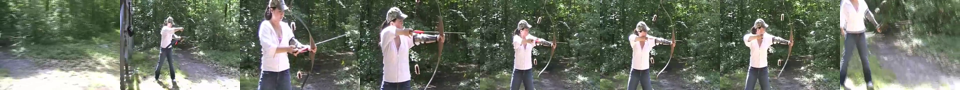

gold: archery
  smolvlm2-500m-video    archery                ok
  qwen3-vl-2b            archery                ok



In [ ]:
# The numbers hide the interesting part: look at the clips the models disagree on.
shown = 0
for i, (path, label) in enumerate(eval_set):
    preds = [r["preds"][i] for r in results]
    if len(set(preds)) == 1 and shown >= 1:
        continue
    display(contact_sheet(subsample(frame_cache[path], 8), cols=8, width=120))
    print(f"gold: {label}")
    for r, p in zip(results, preds):
        answer = CLASSES[p] if p >= 0 else "(unparseable)"
        print(f"  {r['model']:22s} {answer:22s} {'ok' if p == golds[i] else 'WRONG'}")
    print()
    shown += 1
    if shown >= 4:
        break

## 13. Live Demo: ask about the last few seconds

Records a short burst from the webcam, samples it down to a handful of frames, and asks Qwen3-VL-2B what happened. This is the shape of a real streaming pipeline in miniature: capture a rolling window, sample it hard, ask a question, discard.

Two things it makes concrete. First, **capture and inference are serial here** - a 3-second window takes 3 seconds to record and then a couple of seconds to answer, so a live system needs a ring buffer and a worker rather than this loop. Second, **frame sampling is where the information goes**: 3 seconds at 15 FPS is 45 frames and the model sees 8 of them.

This is the cell people run on its own, so it opens with a `require(...)` guard naming what it needs from Setup instead of dying on a bare `NameError`. Capture notes, all measured on the knowledge-lab container: V4L2 backend with MJPEG and a warm-up read (auto-exposure needs frames to settle), never `CAP_PROP_BUFFERSIZE` (it halves the frame rate without making frames fresher), and no `cv2.imshow` because there is no GUI - the preview goes through `IPython.display` handles that update in place.

---

Loading weights:   0%|          | 0/625 [00:00<?, ?it/s]

VRAM live model              4.26 GB allocated /  4.27 GB reserved


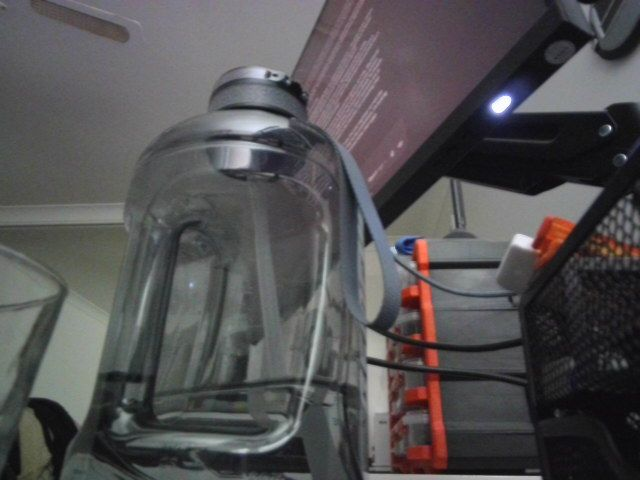

round 3: 49 frames captured over 3.0s, 8 shown to the model, 0.8s to answer

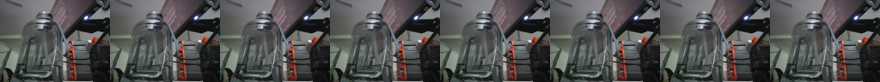

round 1: The person in the video is sitting at a desk with a computer monitor and a large water bottle.



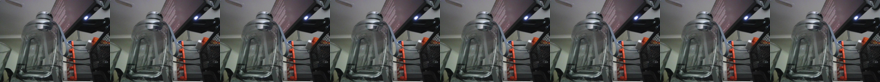

round 2: The person in the video is sitting at a desk with a large water bottle in front of them.



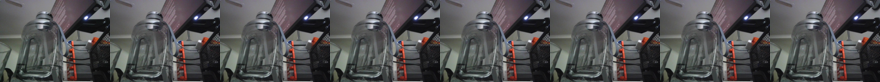

round 3: The person in the video is sitting at a desk with a computer monitor and a large water bottle.

VRAM final                   0.01 GB allocated /  0.01 GB reserved


In [ ]:
def require(*names):
    "Fail early and clearly if the notebook's setup / helper cells have not been run."
    missing = [n for n in names if n not in globals()]
    if missing:
        raise NameError(
            f"this demo needs {', '.join(missing)} from earlier in the notebook. "
            "Run the setup and helper cells first (Run > Run All Above Selected Cell)."
        )


require("device", "dtype", "HF_CACHE", "free_memory", "vram", "qwen_id", "contact_sheet",
        "video_meta")

import time
import numpy as np
import torch

# opencv-python-headless is a project dependency; the headless build captures from
# V4L2 fine, it only drops the GUI windows.
import io

import cv2
from IPython.display import Image as IPyImage
from IPython.display import Pretty, display
from PIL import Image

from transformers import AutoModelForImageTextToText, AutoProcessor

CAM = 0                 # /dev/video0
WARMUP = 10             # throwaway reads - auto-exposure and white balance need to settle
WINDOW_SECONDS = 3      # how much video each question is asked about
FRAMES_PER_WINDOW = 8   # what the model actually sees out of that window
ROUNDS = 3              # how many capture-and-ask cycles to run
QUESTION = "In one sentence, what is the person in this video doing?"


def open_camera(index=CAM, width=640, height=480, auto_exposure=True, exposure=150):
    "Open a V4L2 webcam in MJPEG mode, let it settle, and return the capture handle."
    cap = cv2.VideoCapture(index, cv2.CAP_V4L2)
    if not cap.isOpened():
        raise RuntimeError(
            f"/dev/video{index} did not open - no camera attached, "
            "or it is not passed through into this container"
        )
    cap.set(cv2.CAP_PROP_FOURCC, cv2.VideoWriter.fourcc(*"MJPG"))  # MJPEG unlocks the higher modes
    cap.set(cv2.CAP_PROP_FRAME_WIDTH, width)
    cap.set(cv2.CAP_PROP_FRAME_HEIGHT, height)
    # UVC exposure is DEVICE state and persists between processes: if anything left this
    # camera in manual mode every frame comes back dark and never adapts, so ask for the
    # mode explicitly. auto (3) = correct brightness but 15 FPS in a dim room;
    # manual (1) = locked 30 FPS at whatever `exposure` suits the lighting.
    cap.set(cv2.CAP_PROP_AUTO_EXPOSURE, 3 if auto_exposure else 1)
    if not auto_exposure:
        cap.set(cv2.CAP_PROP_EXPOSURE, exposure)
    # Deliberately no CAP_PROP_BUFFERSIZE: on the V4L2 backend it HALVES the delivered
    # frame rate and does not make frames any fresher.
    for _ in range(WARMUP):
        if not cap.read()[0]:
            cap.release()
            raise RuntimeError(f"/dev/video{index} opened but delivered no frames")
    return cap


def grab(cap):
    "Read one frame off an open camera as an RGB PIL image (OpenCV hands back BGR)."
    ok, frame = cap.read()
    if not ok:
        raise RuntimeError("failed to read a frame")
    return Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))


def _jpeg(img, quality=80):
    "Encode a PIL image to JPEG bytes - what actually goes over the wire each frame."
    buf = io.BytesIO()
    img.convert("RGB").save(buf, format="JPEG", quality=quality)
    return buf.getvalue()


def record_window(cap, seconds=WINDOW_SECONDS, view=None, status=None):
    "Capture `seconds` of live video, showing it as it goes -> (frames, elapsed, view, status)."
    frames, t0 = [], time.perf_counter()
    while time.perf_counter() - t0 < seconds:
        rgb = grab(cap)
        frames.append(rgb)
        img = IPyImage(data=_jpeg(rgb))
        line = Pretty(f"recording {seconds - (time.perf_counter() - t0):4.1f}s left, "
                      f"{len(frames)} frames captured")
        if view is None:
            view = display(img, display_id=True)
            status = display(line, display_id=True)
        else:
            view.update(img)
            status.update(line)
    return frames, time.perf_counter() - t0, view, status


# Re-runnable: this cell frees the model at the end, so guard the load or a second
# shift-enter raises NameError on `live_model`.
if "live_model" not in globals():
    live_proc = AutoProcessor.from_pretrained(qwen_id, cache_dir=HF_CACHE)
    live_model = AutoModelForImageTextToText.from_pretrained(
        qwen_id, dtype=dtype, device_map=device, low_cpu_mem_usage=True, cache_dir=HF_CACHE
    ).eval()
    vram("live model")


def live_ask(frames, prompt, seconds, max_new_tokens=96):
    "PIL frames + the wall-clock seconds they cover + a prompt, through the live model."
    frames = list(frames)
    # Same two rules as `ask` in section 8: the frames are already sampled, so switch the
    # processor's own sampling off, and hand it the real duration or it assumes 24 FPS and
    # timestamps a 3-second window as a third of a second.
    inputs = live_proc.apply_chat_template(
        [{"role": "user", "content": [{"type": "video", "video": frames},
                                      {"type": "text", "text": prompt}]}],
        add_generation_prompt=True, tokenize=True, return_dict=True, return_tensors="pt",
        processor_kwargs={"do_sample_frames": False,
                          "video_metadata": video_meta(frames, seconds)},
    ).to(live_model.device)
    n = inputs["input_ids"].shape[1]
    with torch.inference_mode():
        out = live_model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)
    return live_proc.batch_decode(out[:, n:], skip_special_tokens=True)[0].strip()


cap = open_camera()
view = status = None
try:
    for round_i in range(ROUNDS):
        captured, window, view, status = record_window(cap, view=view, status=status)
        picked = [captured[i] for i in
                  np.linspace(0, len(captured) - 1, FRAMES_PER_WINDOW).round().astype(int)]
        t0 = time.perf_counter()
        answer = live_ask(picked, QUESTION, window)
        status.update(Pretty(f"round {round_i + 1}: {len(captured)} frames captured "
                             f"over {window:.1f}s, {len(picked)} shown to the model, "
                             f"{time.perf_counter() - t0:.1f}s to answer"))
        display(contact_sheet(picked, cols=8, width=110))
        print(f"round {round_i + 1}: {answer}\n")
except KeyboardInterrupt:
    print("stopped")
finally:
    cap.release()  # always hand the device back

del live_model, live_proc
free_memory()
vram("final")

## 14. Going Further

- **Sample smarter, not more.** Uniform sampling is a default, not a strategy. Shot-boundary detection (`scenedetect`, or a cheap frame-difference threshold), keyframe selection by CLIP-similarity to the question, and denser sampling around detected motion all buy more accuracy per token than raising the frame count. For long video this is not an optimisation, it is the only thing that works.
- **Use the audio.** Most video LLMs ignore the soundtrack, and for lectures, meetings and user-generated content that is where the answer lives. Either run ASR (`Audio/02_Automatic_Speech_Recognition`) and put the transcript in the prompt alongside the frames - cheap, effective, and the most common production pattern - or use an omni model that ingests both (`Multimodal/08_Any_to_Any`).
- **Video-RAG for long content.** Segment the video, caption or embed each segment, retrieve the relevant ones for the question, then run the video LLM only on those. This scales to hours where context extension does not, and it gives you citations back to timestamps.
- **Fine-tuning.** LoRA on a 2B video LLM fits this card if you keep frame counts at 8 and resolution modest; `LLaVA-Video-178K` is the standard open instruction set. For a fixed camera and a fixed question set (safety monitoring, sports events), a small **video classifier** (`Computer_Vision/09_Video_Classification`) fine-tuned on your own clips will beat any prompted VLM on accuracy, latency and cost.
- **Always run the ablation.** Section 11 costs one extra pass and tells you whether your evaluation measures what you think. Publish `forward - shuffled` next to your accuracy; if it is near zero, say so.
- **Serving (optional, external).** vLLM and SGLang serve Qwen3-VL and LLaVA-NeXT-Video with continuous batching; frames from one clip share a prefix, so prefix caching helps a lot when asking many questions about one video. `llama.cpp`/GGUF covers SmolVLM2 on edge devices. None are needed for anything above.
- **Related notebooks.** `Multimodal/01_Image_Text_to_Text` (the single-frame case, resolution and structured output), `Computer_Vision/09_Video_Classification` (fixed labels, and the same temporal ablation applied to specialist video models), `Multimodal/00_Audio_Text_to_Text` (the soundtrack), `Multimodal/03_Image_Text_to_Video` (generation rather than understanding), and `Multimodal/08_Any_to_Any` (models that take video, audio and text together).

---